In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dbof.dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.dataset_creation.zarr_grid_global    as zarr_grid
import dbof.io.filesystems as filesystems


# Load GLOBAL PROPERTIES

## Dataset access config

For convenience the parameters used in accessing the dataset can be stored in config files under ```configs/data_access/```.
These values must match the run configurations.

Example config:
```
data_access:
  s3_endpoint: "https://s3-west.nrp-nautilus.io"
  bucket: "llc"
  folder: "native_grid_dbof_training_data"
  run_id: "global_properties_test00"
```

If the user prefers, these values can also simply be hardcoded when using the package.

In [12]:
path_to_config = "../../configs/data_access/global_properties.yaml"
with open(path_to_config) as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg["data_access"]
grid_cfg = cfg["grid_access"]

# ── Snapshot store ─────────────────────────────────────────────────────────────
bucket          = data_cfg["bucket"]
folder          = data_cfg["folder"]
s3_endpoint     = data_cfg["s3_endpoint"]
feature_channels = data_cfg["feature_channels"]
run_id          = data_cfg["run_id"]

# ── Grid store (different path — no run_id prefix) ─────────────────────────────
grid_bucket      = grid_cfg["bucket"]
grid_folder      = grid_cfg["folder"]
grid_s3_endpoint = grid_cfg["s3_endpoint"]
grid_dataset_name = grid_cfg["dataset_name"]

print(f"Snapshot: s3://{bucket}/{folder}/{run_id}/properties.zarr")
print(f"Grid:     s3://{grid_bucket}/{grid_folder}/{grid_dataset_name}")


Snapshot: s3://dbof/native_grid_dbof_training_data/global_properties_20260306_053740/properties.zarr
Grid:     s3://dbof/native_grid_dbof_training_data/llc4320_grid.zarr


# Load the data 

In [13]:
# ── Snapshot reader ────────────────────────────────────────────────────────────
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="properties.zarr",
    fs=fs,
)
print(reader)
print(f"Channels : {reader.channel_names}")
print(f"Timesteps: {reader.n_timesteps}  |  shape: {reader.rectangular_shape}")

# ── Grid reader (may use same or different S3 credentials) ─────────────────────
fs_grid, _ = filesystems.create_s3_filesystems(grid_s3_endpoint)

grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=grid_bucket,
    folder=grid_folder,
    dataset_name=grid_dataset_name,
    fs=fs_grid,
)
print(grid_reader)

# ── Load full-resolution lat/lon (used for region finding & regional plots) ────
# These are (H, W) float32 arrays — loaded once and kept in memory (~3.4 GB total).
XC = grid_reader.lon   # longitude (degrees east), shape (H, W)
YC = grid_reader.lat   # latitude  (degrees north), shape (H, W)
print(f"Grid loaded: XC {XC.shape}, lon [{XC.min():.1f}, {XC.max():.1f}]  "
      f"YC {YC.shape}, lat [{YC.min():.1f}, {YC.max():.1f}]")

# ── Precompute downsampled coords for fast global plotting ─────────────────────
DS_GLOBAL = 20          # 20x downsample → (648, 864) per field, ~fast cartopy render
XC_g = XC[::DS_GLOBAL, ::DS_GLOBAL]   # (H/20, W/20) for global pcolormesh
YC_g = YC[::DS_GLOBAL, ::DS_GLOBAL]


Channels : ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'relative_vorticity', 'strain_n', 'strain_s', 'strain_mag', 'divergence', 'coriolis_f', 'rossby_number', 'okubo_weiss', 'gradb2']
Timesteps: 1  |  shape: (12960, 17280)
GlobalGridZarrReader(shape=(12960, 17280), variables=['XC', 'YC', 'rA', 'Depth', 'SN', 'CS', 'hFacC', 'dxC', 'dyG', 'hFacW', 'rAw', 'dyC', 'dxG', 'hFacS', 'rAs', 'rAz', 'XG', 'YG', 'lat', 'lon'])
Grid loaded: XC (12960, 17280), lon [-180.0, 180.0]  YC (12960, 17280), lat [-90.0, 72.0]


In [14]:
print(f"n_timesteps: {reader.n_timesteps}")
print(f"time array:  {reader.time[:]}")


n_timesteps: 1
time array:  [0]


### Plot global maps

/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


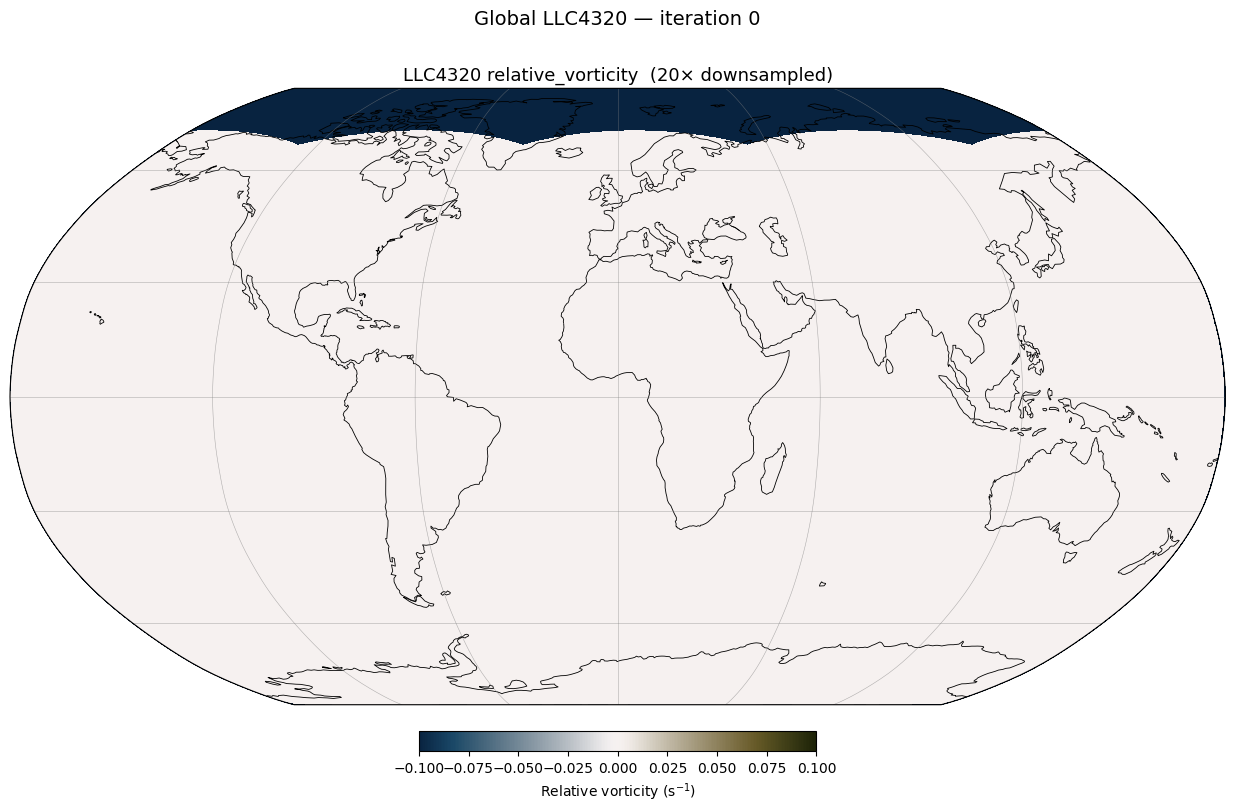

In [15]:
# ── Choose one channel ─────────────────────────────────────────────────────────
target = "relative_vorticity"  

channels = reader.channel_names
try:
    i = channels.index(target)
except ValueError:
    raise ValueError(f"Channel '{target}' not found. Available: {channels}")

# ── Load one channel, downsample to match precomputed grid ────────────────────
arr_ds = reader.get_channel_snapshot(0, i)[::DS_GLOBAL, ::DS_GLOBAL]

finite = arr_ds[np.isfinite(arr_ds)]
vmin, vmax = np.nanpercentile(finite, [1, 99])

# ── Plot on Robinson projection ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im = ax.pcolormesh(XC_g, YC_g, arr_ds,
                   cmap=cmo.diff, vmin=vmin, vmax=vmax,
                   transform=ccrs.PlateCarree(),
                   shading='nearest')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
ax.gridlines(linewidth=0.4, color='gray', alpha=0.6)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label=r'Relative vorticity (s$^{-1}$)', orientation='horizontal')
ax.set_title(f'LLC4320 {target}  ({DS_GLOBAL}× downsampled)', fontsize=13)
plt.suptitle(f'Global LLC4320 — iteration {reader.time[0]}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/lahoffma/mini

ValueError: 'frontogenesis_tendency' is not in list

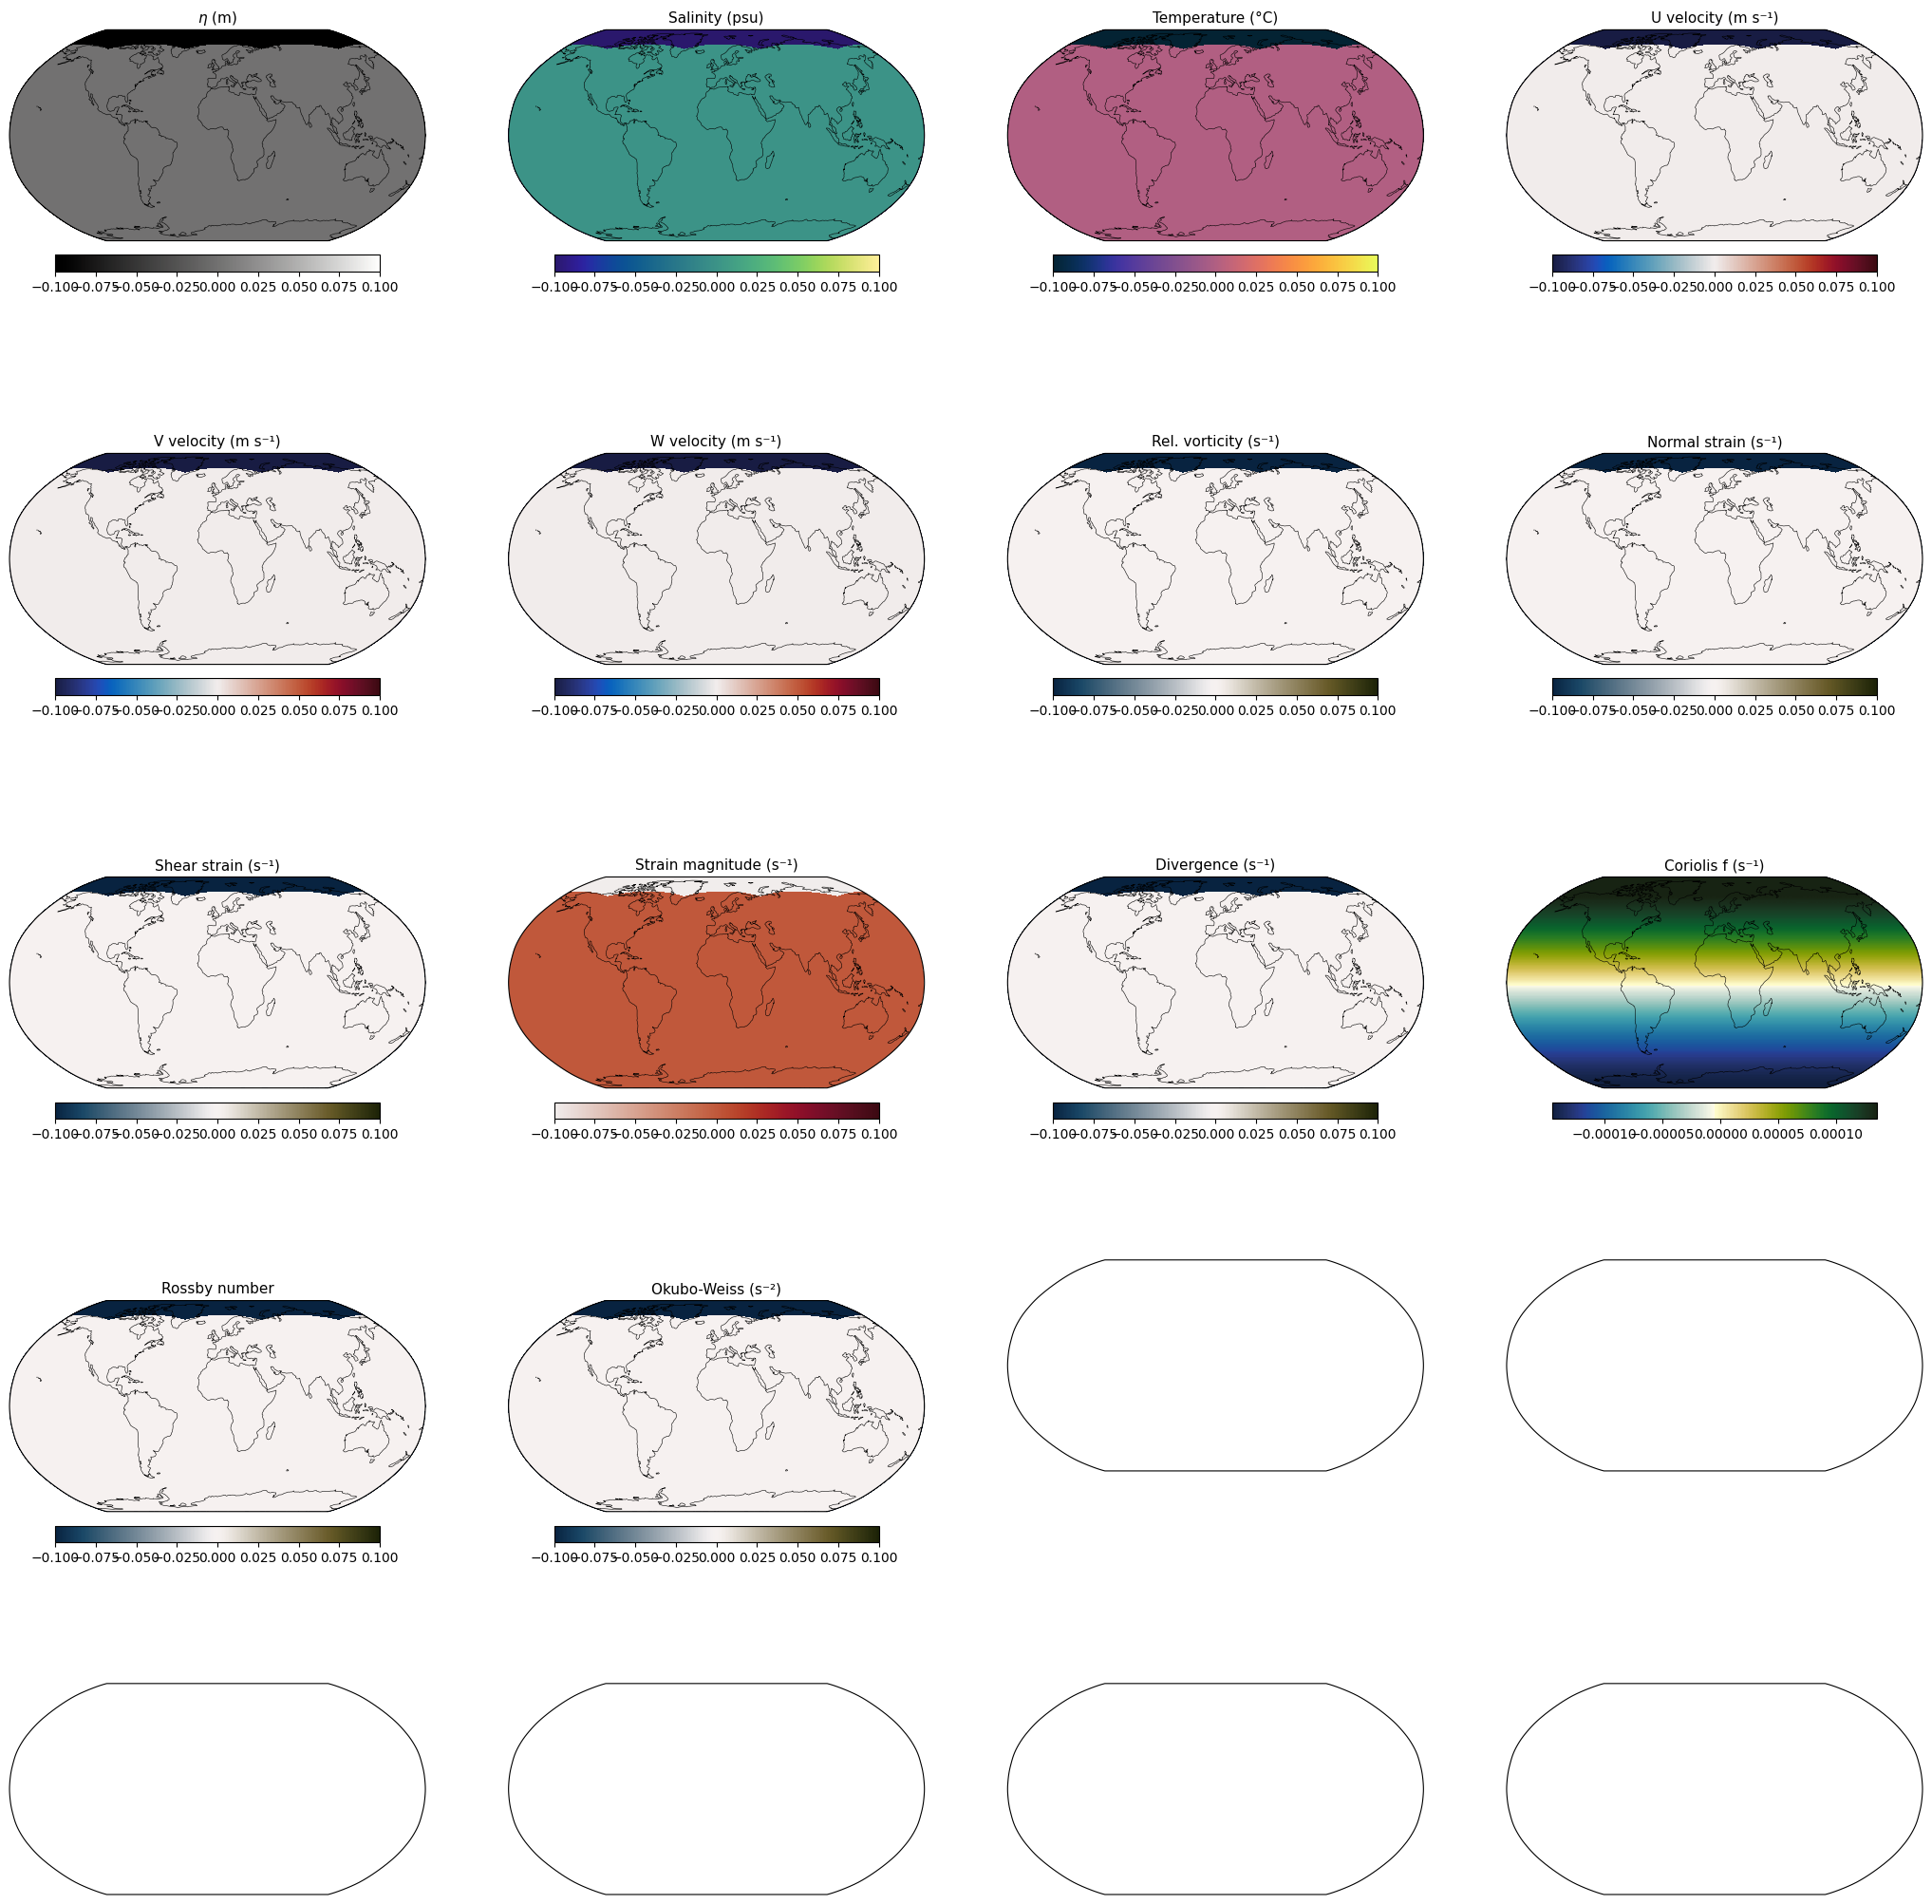

In [5]:
# ── Colormap / label config ────────────────────────────────────────────────────
CMAP_CFG = {
    'Eta':                    ('gray',    r'$\eta$ (m)'),
    'Salt':                   ('haline',  'Salinity (psu)'),
    'Theta':                  ('thermal', 'Temperature (°C)'),
    'U':                      ('balance', 'U velocity (m s⁻¹)'),
    'V':                      ('balance', 'V velocity (m s⁻¹)'),
    'W':                      ('balance', 'W velocity (m s⁻¹)'),
    'relative_vorticity':     ('diff',    'Rel. vorticity (s⁻¹)'),
    'strain_n':               ('diff',    'Normal strain (s⁻¹)'),
    'strain_s':               ('diff',    'Shear strain (s⁻¹)'),
    'strain_mag':             ('amp',     'Strain magnitude (s⁻¹)'),
    'divergence':             ('diff',    'Divergence (s⁻¹)'),
    'coriolis_f':             ('delta',   'Coriolis f (s⁻¹)'),
    'rossby_number':          ('diff',    'Rossby number'),
    'okubo_weiss':            ('diff',    'Okubo-Weiss (s⁻²)'),
    'frontogenesis_tendency': ('diff',    r'$F_{\rm strain}$ (s⁻⁵)'),
    'frontogenesis_geo':      ('diff',    r'$F_{\rm geo}$ (s⁻⁵)'),
    'frontogenesis_ageo':     ('diff',    r'$F_{\rm ageo}$ (s⁻⁵)'),
    'ug':                     ('balance', 'u_g (m s⁻¹)'),
    'vg':                     ('balance', 'v_g (m s⁻¹)'),
    'gradb2':                 ('tempo',   r'$|\nabla b|^2$'),
}
channel_order = [
    'Eta', 'Salt', 'Theta', 'U', 'V', 'W',
    'relative_vorticity', 'strain_n', 'strain_s', 'strain_mag',
    'divergence', 'coriolis_f', 'rossby_number', 'okubo_weiss',
    'frontogenesis_tendency', 'frontogenesis_geo', 'frontogenesis_ageo',
    'ug', 'vg',
    'gradb2',
]
channels = reader.channel_names

# ── 20-panel global overview — Robinson projection, lat/lon from grid ─────────
# One channel loaded at a time (1 chunk per call) → only ~700 MB peak RAM.
ncols, nrows = 4, 5
fig, axes = plt.subplots(
    nrows, ncols, figsize=(26, 28),
    subplot_kw={'projection': ccrs.Robinson()},
)
axes = axes.flatten()

for ax, ch in zip(axes, channel_order):
    arr = reader.get_channel_snapshot(0, ch)[::DS_GLOBAL, ::DS_GLOBAL]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [2, 98])
    im = ax.pcolormesh(XC_g, YC_g, arr,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       shading='nearest')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k')
    ax.set_title(label, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85,
                 orientation='horizontal')

for ax in axes[len(channel_order):]:
    ax.set_visible(False)

plt.suptitle(
    f'Global LLC4320 Properties — iteration {reader.time[0]}  |  {DS_GLOBAL}× downsampled',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


### Plot a property in a specified location.

#### Region selection by lat/lon

The grid (XC, YC) is now loaded — you can select any region by geographic
coordinates. The nearest pixel to your requested **(lat, lon)** centre is found
automatically, and the bounding box is derived from an approximate km-to-pixel
conversion (LLC4320 native resolution ≈ 1/48° ≈ 2.3 km at mid-latitudes).


In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS — edit these to choose your region
# ════════════════════════════════════════════════════════════════════════════════

LAT_CENTER = 36.0       # degrees north
LON_CENTER = -72.0      # degrees east  (use negative for west)
HALF_H_KM  = 1000.0     # approximate half-height of region (km)
HALF_W_KM  = 2000.0     # approximate half-width  of region (km)

# ════════════════════════════════════════════════════════════════════════════════

H, W = reader.rectangular_shape   # (12960, 17280)

# Normalise requested longitude to match XC convention
lon_q = LON_CENTER % 360 if float(XC.max()) > 180 else LON_CENTER

# Find nearest pixel to (LAT_CENTER, lon_q)
dist = np.sqrt((XC - lon_q) ** 2 + (YC - LAT_CENTER) ** 2)
cy, cx = np.unravel_index(int(np.nanargmin(dist)), dist.shape)
print(f"Nearest pixel to ({LAT_CENTER}°N, {LON_CENTER}°E): y={cy}, x={cx}  "
      f"[actual: lat={YC[cy,cx]:.3f}°N, lon={XC[cy,cx]:.3f}°E]")

# Convert km → pixels  (LLC4320 ≈ 1/48° ≈ 2.3 km at mid-latitudes)
KM_PER_PIX = 2.3
HALF_H_PIX = int(HALF_H_KM / KM_PER_PIX)
HALF_W_PIX = int(HALF_W_KM / KM_PER_PIX)

Y_CENTER_PIX, X_CENTER_PIX = cy, cx

# Clamp to image extent
y0 = max(0, cy - HALF_H_PIX)
y1 = min(H, cy + HALF_H_PIX)
x0 = max(0, cx - HALF_W_PIX)
x1 = min(W, cx + HALF_W_PIX)

# Regional grid coords (used for plotting)
XC_reg = XC[y0:y1, x0:x1]
YC_reg = YC[y0:y1, x0:x1]

print(f"Region: rows [{y0}:{y1}], cols [{x0}:{x1}]  →  {y1-y0} × {x1-x0} pixels")
print(f"Geographic extent: lon [{float(XC_reg.min()):.2f}, {float(XC_reg.max()):.2f}]  "
      f"lat [{float(YC_reg.min()):.2f}, {float(YC_reg.max()):.2f}]")


Nearest pixel to (36.0°N, -72.0°E): y=9931, x=15647  [actual: lat=35.996°N, lon=-72.010°E]
Region: rows [9497:10365], cols [14778:16516]  →  868 × 1738 pixels
Geographic extent: lon [-90.11, -53.93]  lat [28.98, 42.46]


/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


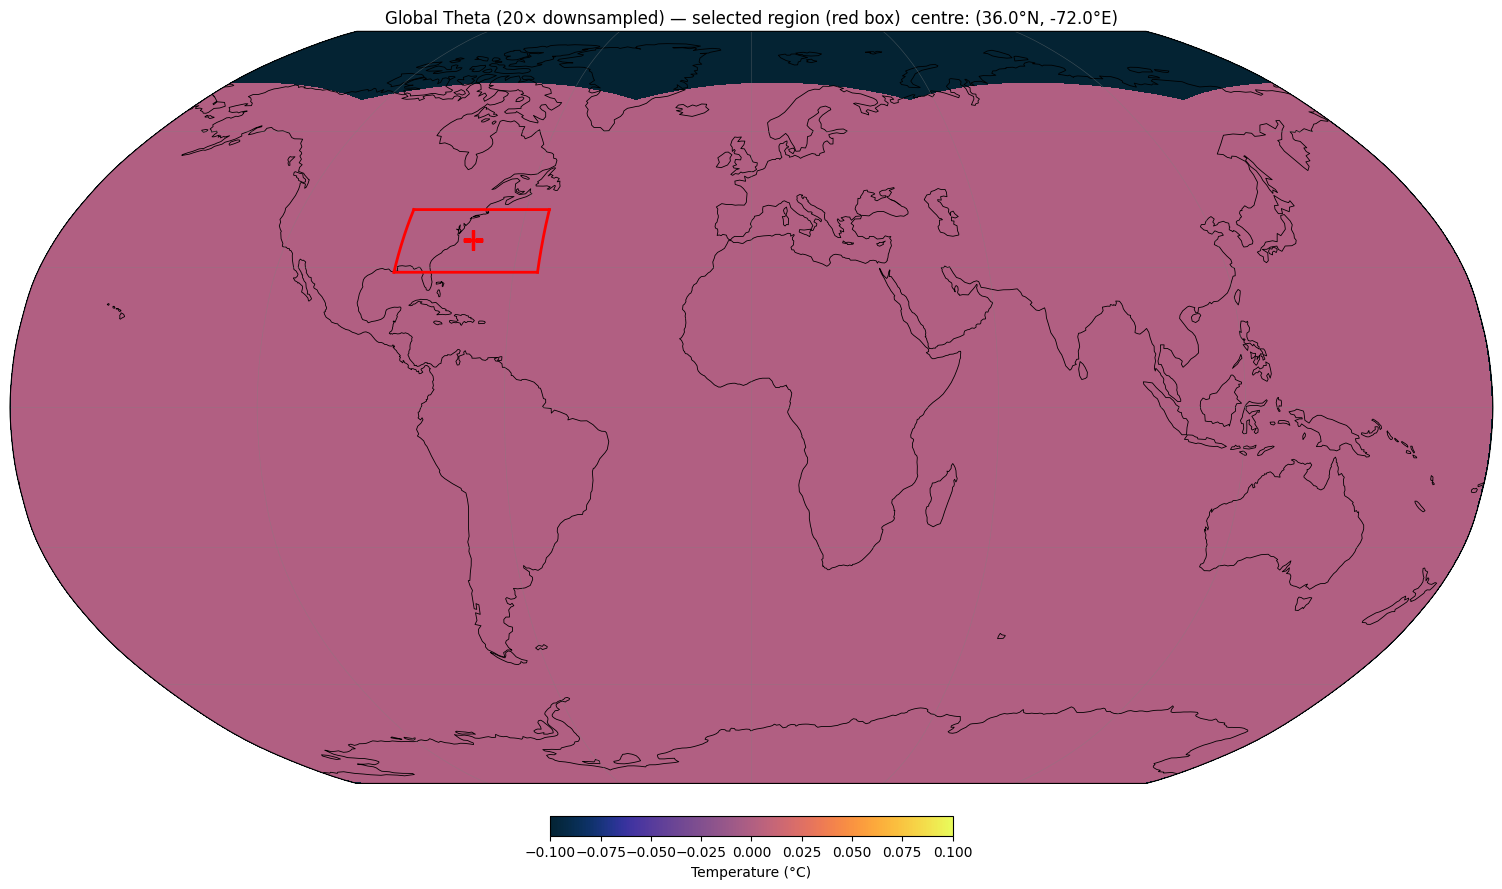

In [17]:
# ── Global Theta (downsampled) with selected region outlined ──────────────────
theta_ds = reader.get_channel_snapshot(0, 'Theta')[::DS_GLOBAL, ::DS_GLOBAL]
vmin_t, vmax_t = np.nanpercentile(theta_ds[np.isfinite(theta_ds)], [2, 98])

fig = plt.figure(figsize=(18, 9))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im = ax.pcolormesh(XC_g, YC_g, theta_ds,
                   cmap=cmo.thermal, vmin=vmin_t, vmax=vmax_t,
                   transform=ccrs.PlateCarree(), shading='nearest')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04, shrink=0.7,
             label='Temperature (°C)', orientation='horizontal')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
ax.gridlines(linewidth=0.4, color='gray', alpha=0.5)

# ── Draw the selection box using the actual grid-boundary lat/lon ─────────────
# (More accurate than a simple rectangle, especially at high latitudes.)
pc = ccrs.PlateCarree()
ax.plot(XC[y0, x0:x1],    YC[y0, x0:x1],    'r-', lw=2, transform=pc)   # top
ax.plot(XC[y1-1, x0:x1],  YC[y1-1, x0:x1],  'r-', lw=2, transform=pc)   # bottom
ax.plot(XC[y0:y1, x0],    YC[y0:y1, x0],    'r-', lw=2, transform=pc)   # left
ax.plot(XC[y0:y1, x1-1],  YC[y0:y1, x1-1],  'r-', lw=2, transform=pc)   # right
ax.plot(float(XC[cy, cx]), float(YC[cy, cx]),
        'r+', markersize=14, markeredgewidth=2.5, transform=pc, zorder=6)

ax.set_title(
    f'Global Theta ({DS_GLOBAL}× downsampled) — selected region (red box)  '
    f'centre: ({LAT_CENTER}°N, {LON_CENTER}°E)',
    fontsize=12,
)
plt.tight_layout()
plt.show()


ValueError: 'frontogenesis_tendency' is not in list

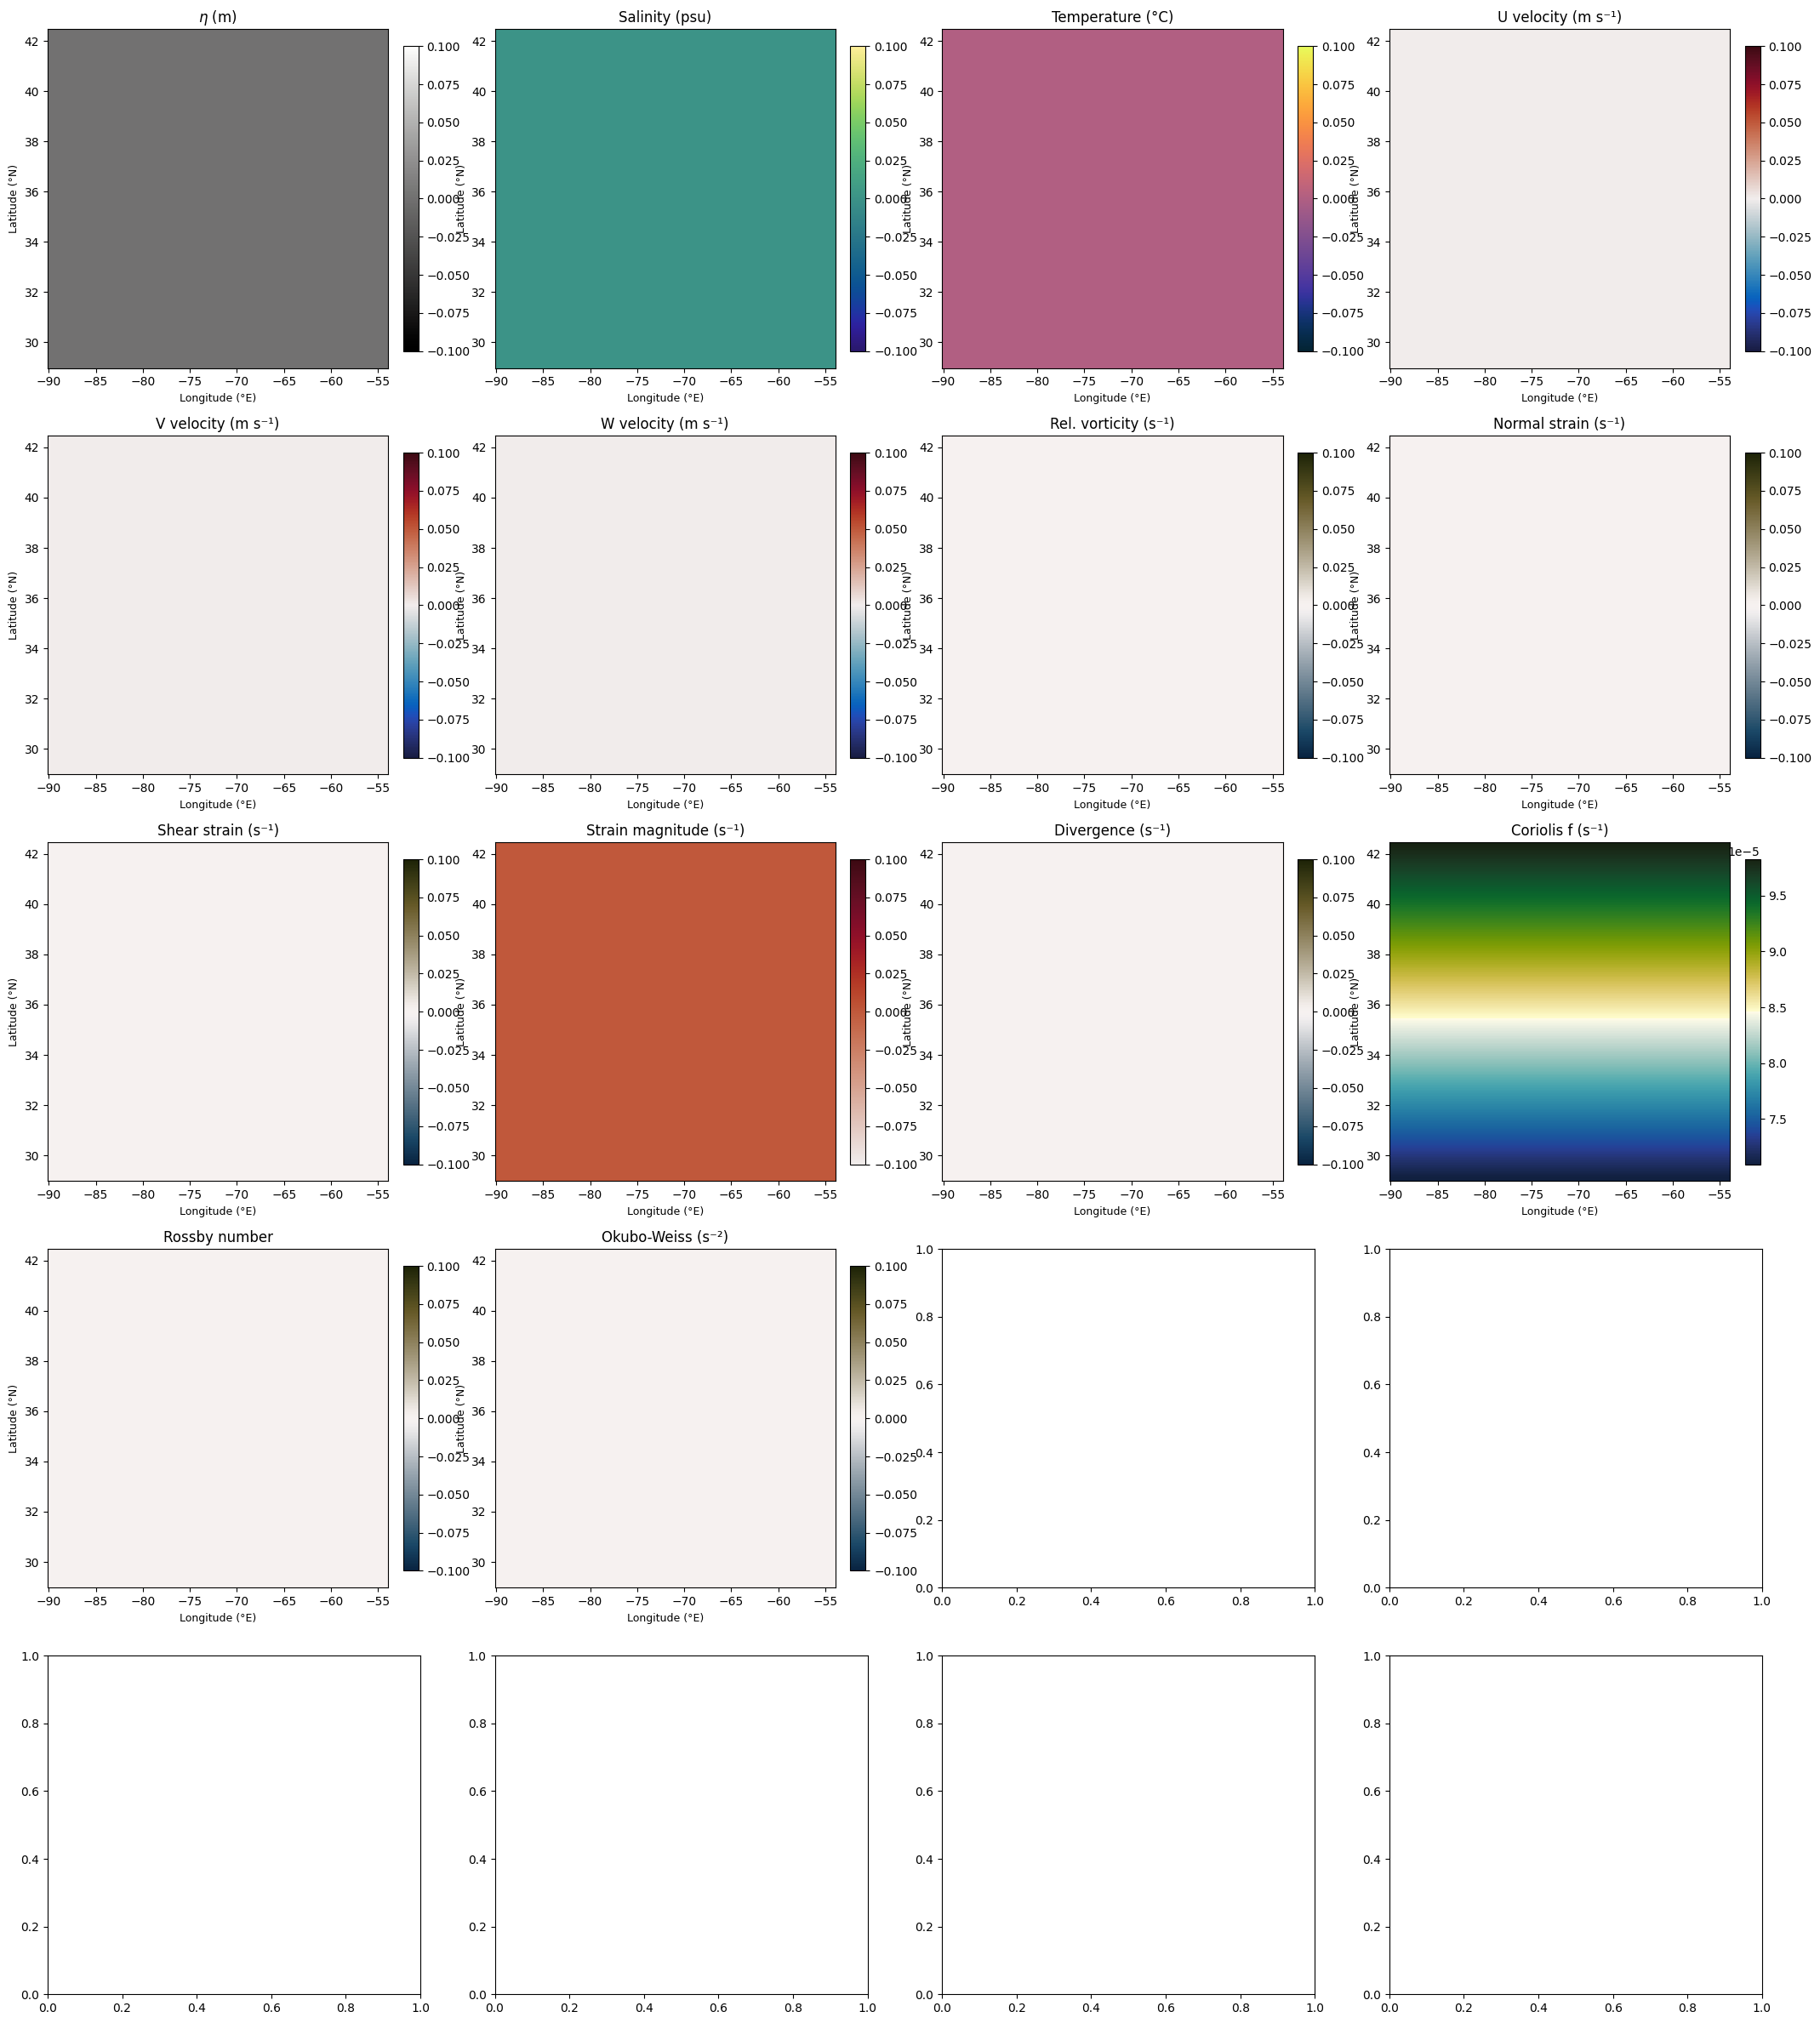

In [18]:
# ── Regional subplots — actual lat/lon coordinates from grid ──────────────────
# Uses XC_reg / YC_reg computed in the settings cell.
# pcolormesh gives correct geographic axes without a full cartopy projection.
ncols, nrows = 4, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(26, nrows * 6))
axes = axes.flatten()

for ax, ch in zip(axes, channel_order):
    arr = reader.get_channel_snapshot(0, ch)[y0:y1, x0:x1]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [1, 99])
    im = ax.pcolormesh(XC_reg, YC_reg, arr,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='nearest')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.set_ylabel('Latitude (°N)',  fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channel_order):]:
    ax.set_visible(False)

plt.suptitle(
    f'Regional Properties — centre ({LAT_CENTER}°N, {LON_CENTER}°E)  |  '
    f'lon [{float(XC_reg.min()):.1f}°, {float(XC_reg.max()):.1f}°]  '
    f'lat [{float(YC_reg.min()):.1f}°, {float(YC_reg.max()):.1f}°]',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()
